# DL066 混合精度与激活重计算

真实按序执行，包含完整重训、可复核输出与内嵌图。所有新输出写入notebook_outputs。

In [1]:
from pathlib import Path
import sys, json, copy, numpy as np, torch
import experiment as e
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
def show(fig):
    b=BytesIO(); fig.savefig(b,format='png',dpi=135,bbox_inches='tight')
    display(Image(data=b.getvalue())); plt.close(fig)
torch.set_num_threads(1)
print({'python':sys.version.split()[0],'torch':torch.__version__,'unit':Path.cwd().name,'device':'CPU'})

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'unit': '066', 'device': 'CPU'}


## 1 三种数值格式

亲自看下溢、溢出与1附近的刻度。

In [2]:
v=torch.tensor([1e-8,1.,1.+2**-10,70000.])
for t in [torch.float32,torch.float16,torch.bfloat16]:print(t,v.to(t).float(),torch.finfo(t).eps)

torch.float32 tensor([1.0000e-08, 1.0000e+00, 1.0010e+00, 7.0000e+04]) 1.1920928955078125e-07
torch.float16 tensor([0.0000, 1.0000, 1.0010,    inf]) 0.0009765625
torch.bfloat16 tensor([1.0012e-08, 1.0000e+00, 1.0000e+00, 7.0144e+04]) 0.0078125


## 2 不等长微批

31、47、50微批须按计数加权。

In [3]:
x,y=e.data();m=e.model();_,a=e.gradients(m,x,y)
for wrong in [False,True]:
    _,b=e.gradients(copy.deepcopy(m),x,y,sizes=[31,47,50],wrong_equal=wrong)
    print('wrong_equal',wrong,'relative error',e.relative_error(a,b))

wrong_equal False relative error 1.272079686032157e-07
wrong_equal True relative error 0.05167796090245247


## 3 正确与错误分支测试

包括Dropout随机状态和BatchNorm反例。

In [4]:
import unittest, test_experiment
result=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not result.wasSuccessful(): raise RuntimeError('unit tests failed')

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 14 tests in 0.779s

OK


## 4 全部三种子四模式重训

真实执行12次160步训练。CPU BF16实际运行；CUDA FP16未运行。

In [5]:
r=e.main(Path('notebook_outputs'))
for z in r['runs']:print(z['seed'],z['mode'],z['final_test_mse'])
print(r['cuda_fp16_gradscaler'])

11 fp32 0.12438774853944778
11 bf16 0.12440479546785355
11 accumulate 0.12438775599002838
11 checkpoint 0.12438774853944778
23 fp32 0.12131506204605103
23 bf16 0.12136544287204742
23 accumulate 0.12131506204605103
23 checkpoint 0.12131506204605103
37 fp32 0.11926794797182083
37 bf16 0.11931803077459335
37 accumulate 0.11926794052124023
37 checkpoint 0.11926794797182083
{'status': 'not_run', 'reason': 'CPU-only verified environment'}


## 5 完整学习曲线

所有终点评价统一FP32推理。

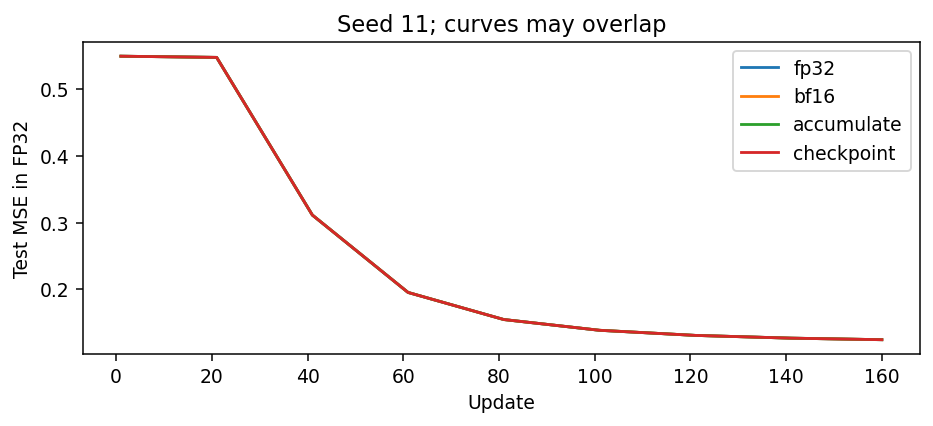

In [6]:
fig,ax=plt.subplots(figsize=(8,3))
for z in r['runs']:
    if z['seed']==11:ax.plot([h['step'] for h in z['history']],[h['test_mse_fp32_inference'] for h in z['history']],label=z['mode'])
ax.set(xlabel='Update',ylabel='Test MSE in FP32',title='Seed 11; curves may overlap');ax.legend();show(fig)

## 6 保存载荷与时间

hooks记录与时间测量在独立运行中。两者都不是GPU峰值。

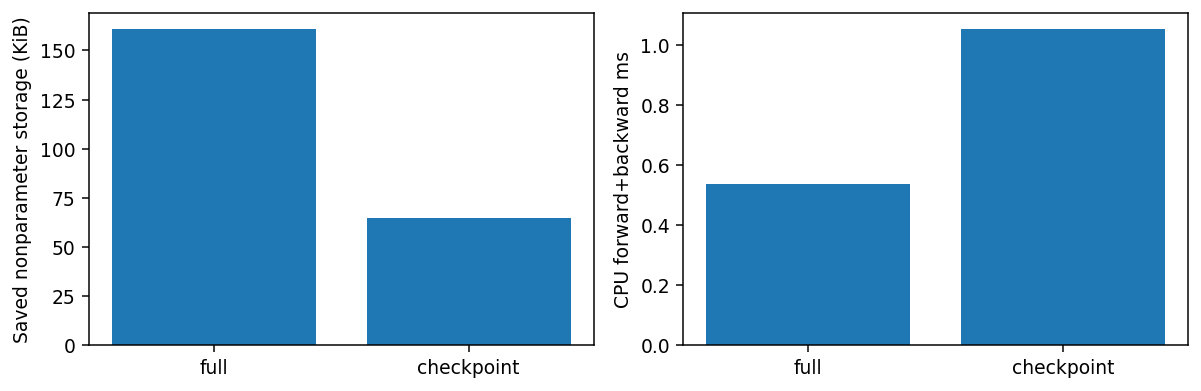

dropout {'preserve_rng_relative_error': 0.0, 'no_preserve_relative_error': 0.5413431525230408}
BatchNorm 0.19860661029815674


In [7]:
fig,axes=plt.subplots(1,2,figsize=(9,3))
keys=['full','checkpoint']
axes[0].bar(keys,[r['saved_tensors'][k]['saved_nonparameter_unique_storage_bytes']/1024 for k in keys]);axes[0].set(ylabel='Saved nonparameter storage (KiB)')
axes[1].bar(keys,[r['timing'][k]['median_seconds']*1000 for k in keys]);axes[1].set(ylabel='CPU forward+backward ms');fig.tight_layout();show(fig)
print('dropout',r['dropout']);print('BatchNorm',r['batchnorm_accumulation_relative_error'])

## 7 复核全部权重

终点权重可复核，但没有完整续训状态。

In [8]:
a=np.load('notebook_outputs/data.npz')
for row in r['runs']:
    z=torch.load(f"notebook_outputs/{row['mode']}_seed{row['seed']}.pt",weights_only=True)
    m=e.model(z['seed']);m.load_state_dict(z['state_dict'])
    with torch.no_grad():value=float(torch.nn.functional.mse_loss(m(torch.from_numpy(a['test_x'])),torch.from_numpy(a['test_y'])))
    if abs(value-row['final_test_mse'])>1e-7:raise RuntimeError('checkpoint mismatch')
print('12 checkpoints reproduced')

12 checkpoints reproduced
